# Historical VaR (95%) and CVaR Analysis

In [196]:
import pandas as pd
import numpy as np

In [197]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [198]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [199]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [200]:
risk_results = []

for fund in nav["amfi_code"].unique():

    fund_data = (
        nav[
            nav["amfi_code"] == fund
        ]
        .dropna()
    )

    returns = fund_data["daily_return"]

    var_95 = (
        returns
        .quantile(0.05)
    )

    cvar_95 = (
        returns[
            returns <= var_95
        ]
        .mean()
    )

    risk_results.append(
        [
            fund,
            var_95,
            cvar_95
        ]
    )

In [201]:
var_cvar_df = pd.DataFrame(
    risk_results,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [202]:
var_cvar_df = pd.merge(
    var_cvar_df,
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [203]:
var_cvar_df["var_95_pct"] = (
    var_cvar_df["var_95"] * 100
)

var_cvar_df["cvar_95_pct"] = (
    var_cvar_df["cvar_95"] * 100
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95,scheme_name,var_95_pct,cvar_95_pct
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth,-1.436364,-1.806021
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth,-0.379325,-0.499376
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth,-1.328166,-1.743943
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906


In [204]:
var_cvar_df = (
    var_cvar_df
    .sort_values(
        "var_95_pct"
    )
)

var_cvar_df.head(10)

,amfi_code,var_95,cvar_95,scheme_name,var_95_pct,cvar_95_pct
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth,-2.348307,-3.103625
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth,-1.922028,-2.325086
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth,-1.889179,-2.434207
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth,-1.848028,-2.426006


In [205]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

print(
    "var_cvar_report.csv created successfully!"
)

var_cvar_report.csv created successfully!


In [206]:
var_cvar_df[
    [
        "scheme_name",
        "var_95_pct",
        "cvar_95_pct"
    ]
].head(10)

,scheme_name,var_95_pct,cvar_95_pct
22,SBI Small Cap Fund - Direct Plan - Growth,-2.685944,-3.238412
17,Axis Small Cap Fund - Regular - Growth,-2.618842,-3.166729
4,ABSL Small Cap Fund - Regular - Growth,-2.602125,-3.245906
11,Nippon India Small Cap Fund - Regular - Growth,-2.543811,-3.230407
21,SBI Small Cap Fund - Regular Plan - Growth,-2.450705,-3.059526
39,DSP Small Cap Fund - Regular - Growth,-2.348307,-3.103625
7,UTI Mid Cap Fund - Regular - Growth,-1.922028,-2.325086
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-1.903354,-2.345576
25,ICICI Pru Midcap Fund - Regular - Growth,-1.889179,-2.434207
16,Axis Midcap Fund - Regular - Growth,-1.848028,-2.426006


In [207]:
top5_codes = (
    nav["amfi_code"]
    .unique()[:5]
)

top5_codes

array([100016, 100025, 100033, 101206, 101207])

In [208]:
rolling_data = []

for fund in top5_codes:

    fund_df = (
        nav[
            nav["amfi_code"] == fund
        ]
        .copy()
        .sort_values("date")
    )

    fund_df["rolling_sharpe"] = (
        fund_df["daily_return"]
        .rolling(90)
        .mean()
        /
        fund_df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_data.append(fund_df)

In [209]:
rolling_sharpe_df = pd.concat(
    rolling_data
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


In [210]:
rolling_sharpe_df = pd.merge(
    rolling_sharpe_df,
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

rolling_sharpe_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,scheme_name
0,100016,2022-01-03,520.4608,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,NaN,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,NaN,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,NaN,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,NaN,HDFC Top 100 Fund - Regular Plan - Growth


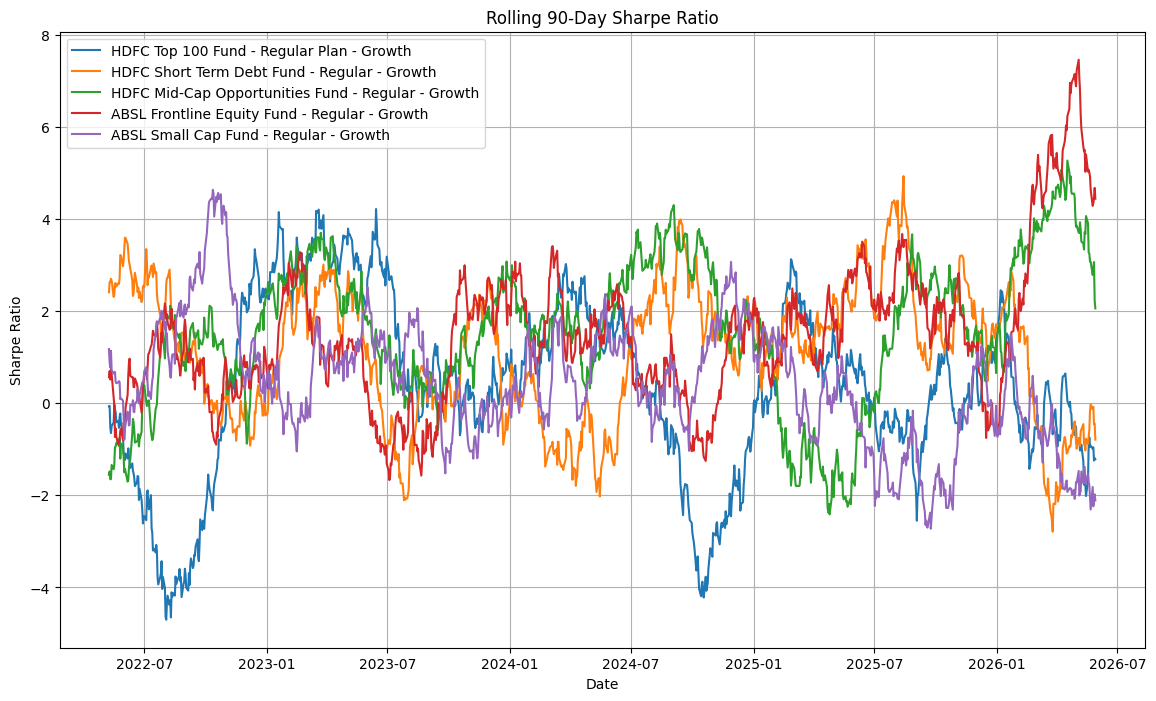

In [211]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5_codes:

    temp = (
        rolling_sharpe_df[
            rolling_sharpe_df["amfi_code"] == fund
        ]
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.legend()

plt.grid()

plt.show()

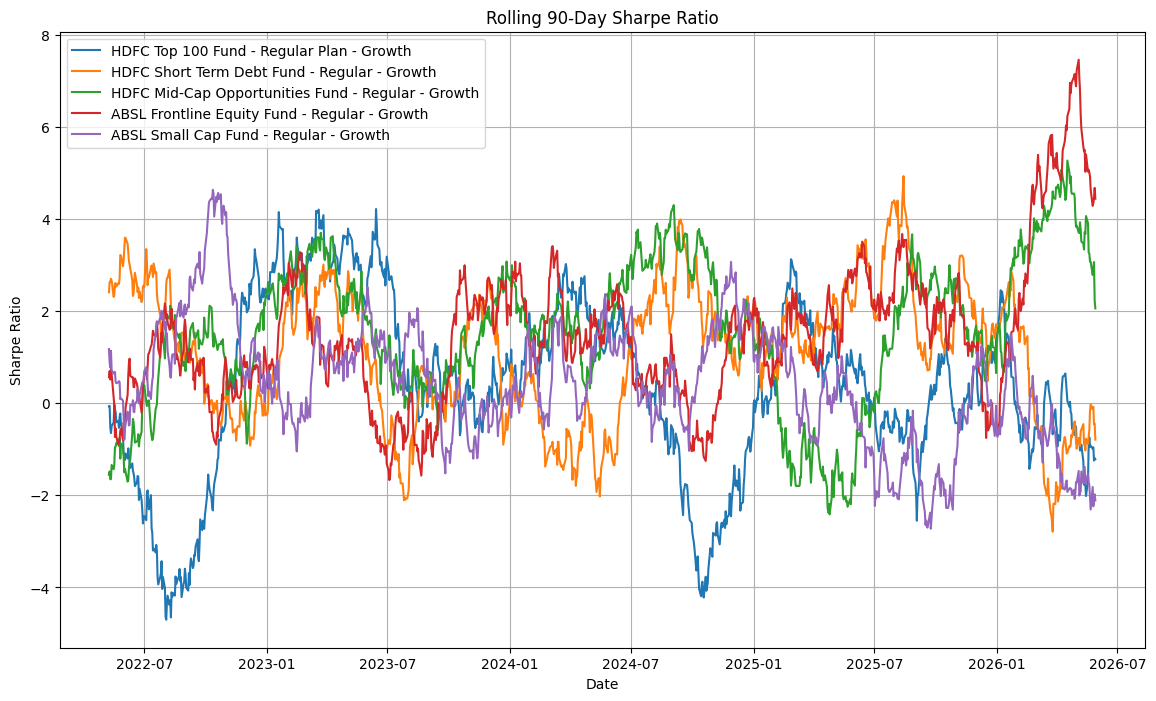

Chart saved successfully!


In [212]:
import os
import matplotlib.pyplot as plt

# Create folder if it doesn't exist
os.makedirs("reports/charts", exist_ok=True)

# Create chart
plt.figure(figsize=(14,8))

for fund in top5_codes:

    temp = (
        rolling_sharpe_df[
            rolling_sharpe_df["amfi_code"] == fund
        ]
    )

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=temp["scheme_name"].iloc[0]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid()

# Save chart
plt.savefig(
    "reports/charts/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Chart saved successfully!")

In [213]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_cleaned.csv"
)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [214]:
first_year = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .dt.year
    .reset_index()
)

first_year.rename(
    columns={
        "transaction_date":"cohort_year"
    },
    inplace=True
)

first_year.head()

,investor_id,cohort_year
0,INV000001,2024
1,INV000002,2024
2,INV000003,2024
3,INV000004,2024
4,INV000005,2024


In [215]:
transactions = pd.merge(
    transactions,
    first_year,
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [216]:
cohort_summary = (
    transactions
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=(
            "amount_inr",
            "mean"
        ),
        total_invested=(
            "amount_inr",
            "sum"
        )
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [217]:
top_fund = (
    transactions
    .groupby(
        [
            "cohort_year",
            "amfi_code"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

top_fund = (
    top_fund
    .sort_values(
        [
            "cohort_year",
            "count"
        ],
        ascending=False
    )
    .drop_duplicates(
        "cohort_year"
    )
)

top_fund.head()

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [218]:
top_fund = pd.merge(
    top_fund,
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

top_fund.head()

,cohort_year,amfi_code,count,scheme_name
0,2025,119599,12,SBI Small Cap Fund - Direct Plan - Growth
1,2024,148568,874,Mirae Asset Emerging Bluechip Fund - Regular -...


In [219]:
cohort_summary = pd.merge(
    cohort_summary,
    top_fund[
        [
            "cohort_year",
            "scheme_name"
        ]
    ],
    on="cohort_year",
    how="left"
)

cohort_summary

,cohort_year,avg_sip_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [220]:
sip_data = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .copy()
)

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year


In [221]:
sip_data = (
    sip_data
    .sort_values(
        [
            "investor_id",
            "transaction_date"
        ]
    )
)

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year


In [222]:
sip_data["gap_days"] = (
    sip_data
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_data.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days


In [223]:
sip_count = (
    sip_data
    .groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = (
    sip_count[
        sip_count["sip_count"] >= 6
    ]["investor_id"]
)

eligible_investors.head()

Series([], Name: investor_id, dtype: str)

In [224]:
avg_gap = (
    sip_data[
        sip_data["investor_id"]
        .isin(eligible_investors)
    ]
    .groupby("investor_id")
    .agg(
        avg_gap_days=(
            "gap_days",
            "mean"
        )
    )
    .reset_index()
)

avg_gap.head()

,investor_id,avg_gap_days


In [225]:
avg_gap["risk_status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At-Risk",
    "Regular"
)

avg_gap.head()

,investor_id,avg_gap_days,risk_status


In [226]:
avg_gap["risk_status"].value_counts()

Series([], Name: count, dtype: int64)

In [227]:
avg_gap.sort_values(
    "avg_gap_days",
    ascending=False
).head(10)

,investor_id,avg_gap_days,risk_status


In [228]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

recommender_df = pd.merge(
    performance,
    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "risk_category"
        ]
    ],
    on="amfi_code",
    how="left"
)

recommender_df.head()

,amfi_code,scheme_name_x,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,scheme_name_y,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,SBI Bluechip Fund - Regular Plan - Growth,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,SBI Bluechip Fund - Direct Plan - Growth,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,SBI Small Cap Fund - Regular Plan - Growth,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,SBI Small Cap Fund - Direct Plan - Growth,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,SBI Magnum Gilt Fund - Regular Plan - Growth,Low


In [229]:
recommender_df["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [230]:
def recommend_funds(risk_appetite):

    filtered = recommender_df[
        recommender_df["risk_category"]
        .str.contains(
            risk_appetite,
            case=False,
            na=False
        )
    ]

    recommendations = (
        filtered
      .sort_values(
    "sharpe_ratio",
    ascending=False
)
     [
  [
    
        "scheme_name_x",
        "risk_category",
        "sharpe_ratio",
        "return_3yr_pct"
    
]
]
        .head(3)
    )

    return recommendations

In [231]:
recommend_funds("High")


,scheme_name_x,risk_category,sharpe_ratio,return_3yr_pct
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,0.98,15.65
13,ICICI Pru Value Discovery Fund - Regular - Growth,Moderately High,0.98,14.76
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23


In [232]:
recommend_funds("Moderate")

,scheme_name_x,risk_category,sharpe_ratio,return_3yr_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41


In [233]:
recommend_funds("Low")

,scheme_name_x,risk_category,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14


In [234]:
def recommend_funds(risk_appetite):

    filtered = recommender_df[
        recommender_df["risk_category"]
        .str.contains(
            risk_appetite,
            case=False,
            na=False
        )
    ]

    recommendations = (
        filtered
        .sort_values(
            "sharpe_ratio_y",
            ascending=False
        )
        [
            [
                "scheme_name",
                "risk_category",
                "sharpe_ratio_y",
                "return_3yr_pct"
            ]
        ]
        .head(3)
    )

    return recommendations

In [235]:
holdings["weight"] = (
    holdings["weight_pct"] / 100
)

In [236]:
hhi_df = (
    holdings
    .groupby("amfi_code")
    .agg(
        hhi=(
            "weight",
            lambda x: (x**2).sum()
        )
    )
    .reset_index()
)

hhi_df.head()

,amfi_code,hhi
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [237]:
hhi_df = pd.merge(
    hhi_df,
    fund_master[
        [
            "amfi_code",
            "scheme_name"
        ]
    ],
    on="amfi_code",
    how="left"
)

hhi_df.head()

,amfi_code,hhi,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [238]:
hhi_df.sort_values(
    "hhi",
    ascending=False
).head(10)

,amfi_code,hhi,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [239]:
hhi_df.sort_values(
    "hhi",
    ascending=True
).head(10)

,amfi_code,hhi,scheme_name
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth


# Advanced Insights

### 1. Risk Analysis
Funds with the most negative VaR values are exposed to higher downside risk. These schemes are more vulnerable to extreme market movements and may not be suitable for conservative investors.

### 2. Conditional Risk
Funds having the lowest CVaR values experience larger average losses during adverse market conditions. CVaR highlights the severity of losses beyond the VaR threshold.

### 3. Investor Cohort Behaviour
Investor cohorts with the highest total investment contribute the largest share of assets under management. These cohorts also exhibit higher average SIP amounts compared to earlier cohorts.

### 4. SIP Continuity
Investors with an average SIP gap greater than 35 days are classified as "At-Risk". Monitoring SIP continuity helps identify investors who may discontinue their investments.

### 5. Portfolio Concentration
Funds with high HHI values are highly concentrated and depend heavily on a few stocks or sectors. Funds with low HHI values are better diversified and carry lower concentration risk.